<h1> Student Success Prediction using Machine learning</h>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score,learning_curve, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import auc,confusion_matrix, roc_curve, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - Machine Learning/Generic Projects/Student Success

/content/drive/MyDrive/Machine learning 2024/Notebooks - Machine Learning/Generic Projects/Student Success


### Read the dataset

In [27]:
data = pd.read_csv("dataset.csv", sep=";")

In [28]:
data.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,12,1,17,0,12,1,22,27,10,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,12,1,1,1,13,28,8,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,9,4,11,1,1,1,22,27,10,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,10,1,1,15,1,1,10,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,10,1,1,1,1,14,5,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [29]:
data.shape

(4424, 35)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [31]:
data.describe(include="all")

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


### check if the dataset has null values

In [32]:
data.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


### Count the number of every class in the output

<ipython-input-33-5df8f3be2699>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data.Target, palette="bwr")


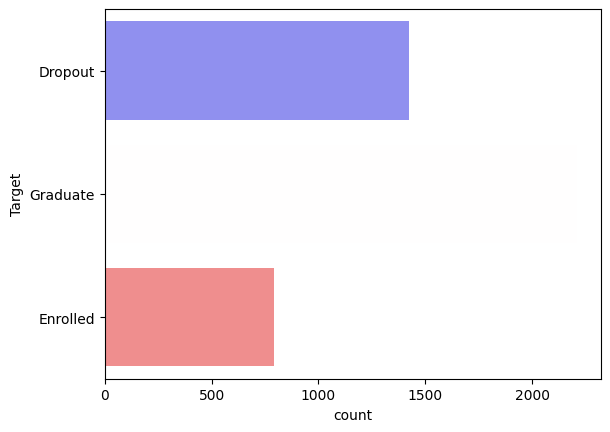

,proportion
Target,
Graduate,0.499322
Dropout,0.321203
Enrolled,0.179476


In [33]:
sns.countplot(data.Target, palette="bwr")
plt.show()
data.Target.value_counts(normalize=True)

## Convert Dropout =0, Graduate=1, Enrolled=3

In [34]:
data = pd.read_csv("dataset.csv", sep=";")
data["Target"]=data.Target.map(dict( Dropout =0, Graduate=1, Enrolled=2))

### select only Dropout and Graduate because the number of Enrolled students is very low

In [35]:
data = data[data['Target'] != 2]

### Read the input and the output

In [36]:
X = data.drop("Target",axis=1)
y = data["Target"]

In [37]:
X.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,6,1,11,1,1,1,1,3,4,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,5,1,1,1,22,27,10,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,8,2,15,1,1,1,23,27,6,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,12,1,3,0,1,1,22,28,10,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [38]:
y.head()

,Target
0,0
1,1
2,0
3,1
4,1


In [39]:
# prompt: apply min max scaler on X and convert the output to datafram with the colimns names

import pandas as pd
from sklearn.preprocessing import MinMaxScaler  # 0 to 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [40]:
from sklearn.feature_selection import SelectKBest, chi2

SelKpest = SelectKBest(chi2, k=20)
X_new=SelKpest.fit_transform(X_scaled,y)
print("the new shape is : ", X_new.shape)

the new shape is :  (3630, 20)


In [41]:
SelKpest.get_support()

array([ True,  True,  True, False, False,  True, False, False, False,
       False, False,  True, False,  True,  True,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True,  True,  True,
       False,  True,  True,  True, False, False, False])

In [42]:
print(X.columns[SelKpest.get_support()].to_list())
X=X_new


['Marital status', 'Application mode', 'Application order', 'Previous qualification', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']


<Axes: >

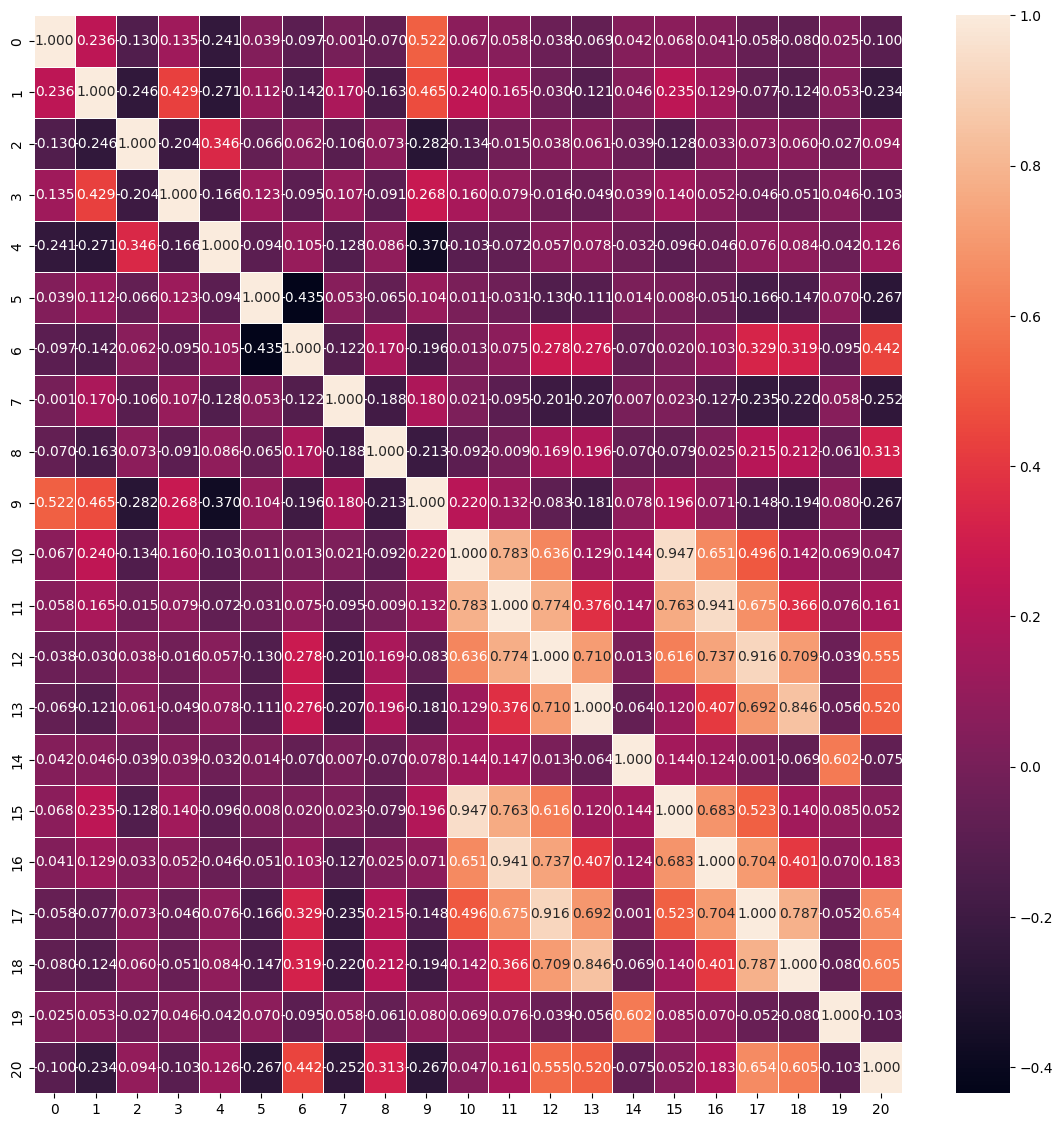

In [43]:
data=np.column_stack([X, y])
data = pd.DataFrame(data)
f,ax = plt.subplots(figsize=(14,14))
sns.heatmap(data.corr(), annot=True, linewidths=.5, fmt= '.3f',ax=ax)

## Data scaling

## Data splitting

In [44]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=10)

## Build models

## Decision Tree

In [45]:
model = DecisionTreeClassifier(random_state=42)
params = {'splitter': ["best", "random"],
          'max_depth': np.arange(1,10,1),
          'min_samples_leaf': np.arange(1,5,1),
          'min_samples_split': np.arange(2,5,1)
         }
cv_dt = GridSearchCV(model, param_grid=params, scoring="accuracy", n_jobs=-1,cv=5)
cv_dt.fit(X_train, y_train)

best_DT=cv_dt.best_estimator_
y_pred = best_DT.predict(X_test)
print(cv_dt.best_params_, cv_dt.best_score_)

{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'} 0.8887767820048669


              precision    recall  f1-score   support

           0     0.8952    0.8367    0.8650       245
           1     0.9195    0.9501    0.9346       481

    accuracy                         0.9118       726
   macro avg     0.9074    0.8934    0.8998       726
weighted avg     0.9113    0.9118    0.9111       726



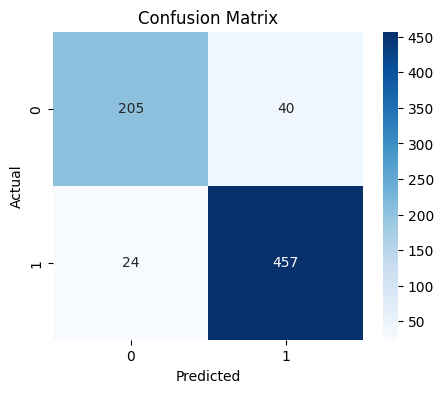

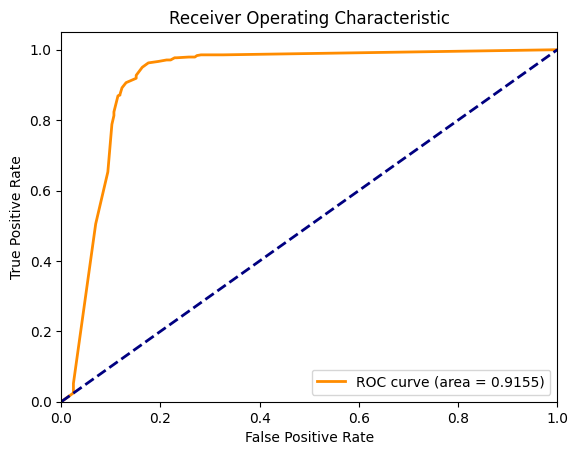

In [46]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  Draw the roc curev and auc using the results of random forest
# ROC Curve and AUC
y_pred_proba = best_DT.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Random Forest implementation

In [47]:
model = RandomForestClassifier(random_state=42)
params = {'n_estimators': np.arange(100,500,100)}
cv_rf = GridSearchCV(model, param_grid=params, scoring="accuracy", n_jobs=-1, cv=5,verbose=3)
cv_rf.fit(X_train, y_train)
best_RF=cv_rf.best_estimator_
y_pred = best_RF.predict(X_test)
print(cv_rf.best_params_, cv_rf.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'n_estimators': 100} 0.8977280550774527


              precision    recall  f1-score   support

           0     0.9381    0.8653    0.9002       245
           1     0.9340    0.9709    0.9521       481

    accuracy                         0.9353       726
   macro avg     0.9360    0.9181    0.9262       726
weighted avg     0.9354    0.9353    0.9346       726



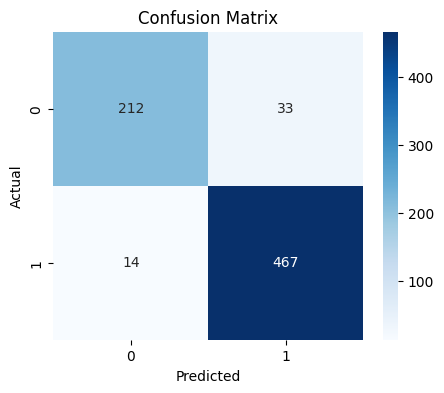

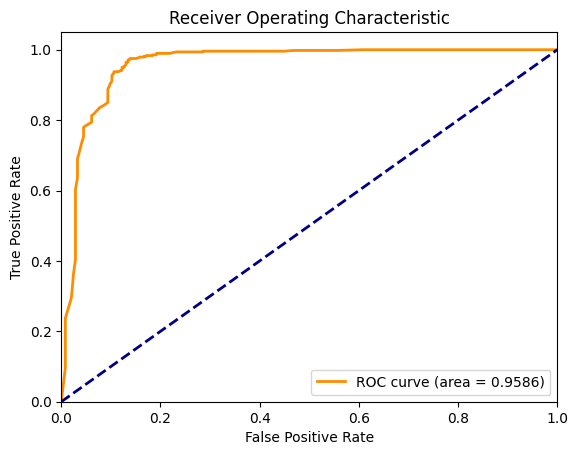

In [48]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  Draw the roc curev and auc using the results of random forest
# ROC Curve and AUC
y_pred_proba = best_RF.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## XGBoost Classifier

In [49]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
# A parameter grid for XGBoost
params = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

xgb = XGBClassifier(learning_rate=0.02, n_estimators=600, objective='binary:logistic',
                    silent=True, nthread=1)

folds = 5
param_comb = 5

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

random_search = RandomizedSearchCV(xgb, param_distributions=params, n_iter=param_comb, scoring='accuracy',
                                   n_jobs=-1, cv=skf.split(X_train,y_train), verbose=3, random_state=1001 )

random_search.fit(X_train,y_train)
best_XGB=random_search.best_estimator_
y_pred = best_XGB.predict(X_test)
print(random_search.best_params_, random_search.best_score_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [09:03:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "silent" } are not used.

  warnings.warn(smsg, UserWarning)


{'subsample': 0.6, 'min_child_weight': 1, 'max_depth': 5, 'gamma': 1.5, 'colsample_bytree': 0.8} 0.9059878924565256


              precision    recall  f1-score   support

           0     0.9498    0.8490    0.8966       245
           1     0.9270    0.9771    0.9514       481

    accuracy                         0.9339       726
   macro avg     0.9384    0.9131    0.9240       726
weighted avg     0.9347    0.9339    0.9329       726



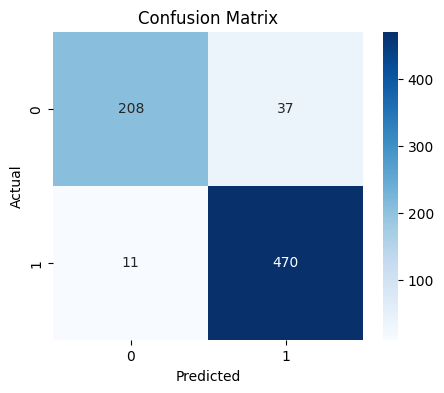

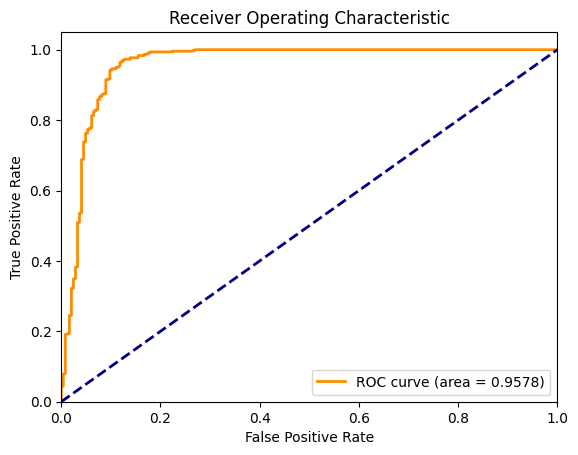

In [50]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  Draw the roc curev and auc using the results of random forest
# ROC Curve and AUC
y_pred_proba = best_XGB.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## MLP implementation

In [51]:
from sklearn.neural_network import MLPClassifier
mlp_gs = MLPClassifier(max_iter=300)
parameter_space = {
    'hidden_layer_sizes': [(10,30,10),(20,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(mlp_gs, parameter_space, n_jobs=-1, cv=5)
clf.fit(X_train, y_train) # X is train samples and y is the corresponding labels
best_MLP=clf.best_estimator_
y_pred=best_MLP.predict(X_test)

              precision    recall  f1-score   support

           0     0.9301    0.8694    0.8987       245
           1     0.9356    0.9667    0.9509       481

    accuracy                         0.9339       726
   macro avg     0.9329    0.9181    0.9248       726
weighted avg     0.9338    0.9339    0.9333       726



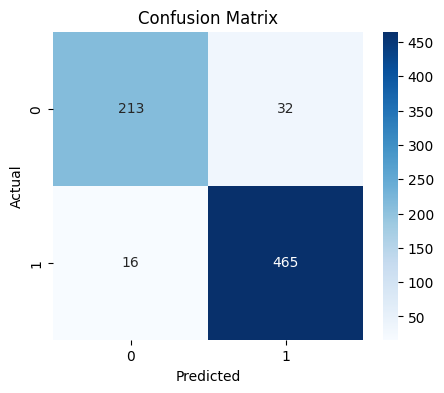

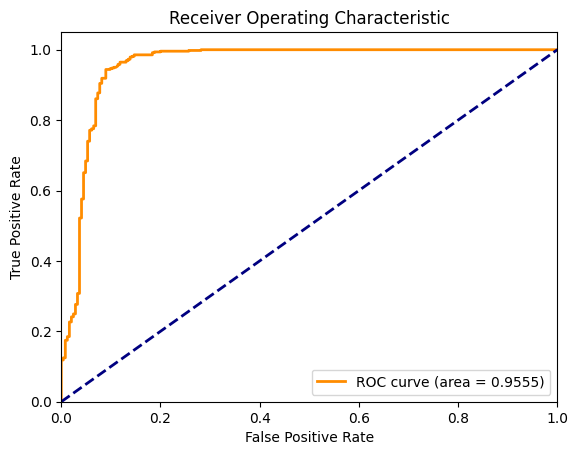

In [52]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  Draw the roc curev and auc using the results of random forest
# ROC Curve and AUC
y_pred_proba = best_MLP.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## VotingClassifier

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


eclf = VotingClassifier(estimators=[
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression()),
    ('rf', RandomForestClassifier(n_estimators= 300)),
    ('dt', DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, splitter= 'random')),
    ('xgb', XGBClassifier(subsample= 0.8, min_child_weight= 5, max_depth= 5, gamma= 1, colsample_bytree= 0.8)),
    ('mlp', MLPClassifier(activation= 'relu', alpha= 0.0001, hidden_layer_sizes= (20,), learning_rate= 'adaptive', solver= 'adam')),
    ('bagging',BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, splitter= 'random'))),
    ('adaboost',AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, splitter= 'random')))
    ], voting='soft')

#Use the key for the classifier followed by __ and the attribute
params = {'lr__C': [1.0, 100.0],
      'svm__C': [2,3,4],
          }

grid = GridSearchCV(estimator=eclf, param_grid=params, cv=5,n_jobs=-1, verbose=3)

grid.fit(X_train,y_train)
print (grid.best_params_)
best_VC=grid.best_estimator_
y_pred=best_VC.predict(X_test)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:156:

{'lr__C': 100.0, 'svm__C': 4}


              precision    recall  f1-score   support

           0     0.9583    0.8449    0.8980       245
           1     0.9255    0.9813    0.9526       481

    accuracy                         0.9353       726
   macro avg     0.9419    0.9131    0.9253       726
weighted avg     0.9366    0.9353    0.9342       726



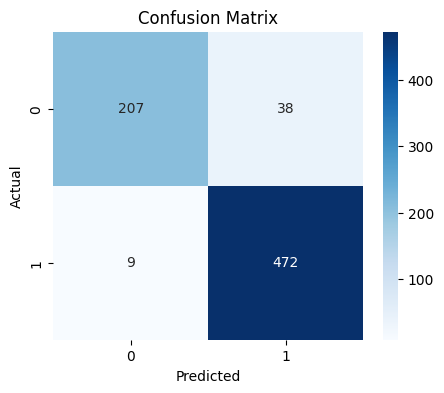

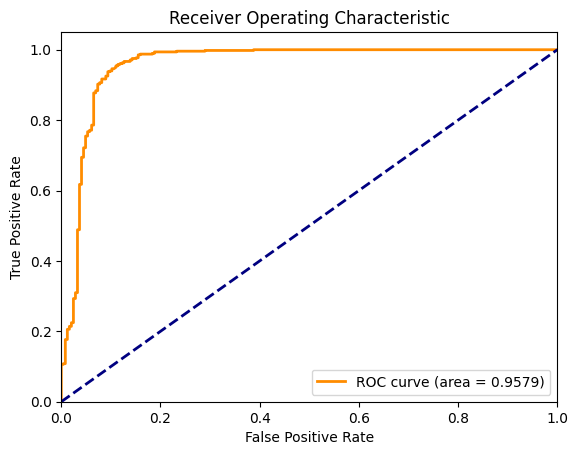

In [55]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  Draw the roc curev and auc using the results of random forest
# ROC Curve and AUC
y_pred_proba = best_VC.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Stacking Classifier

In [56]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier

# define the base models
level0 = list()
level0.append(('LR', LogisticRegression(C= 0.1, penalty='l2')))
level0.append(('RF',RandomForestClassifier(n_estimators= 300)))
level0.append(('DT', DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, splitter= 'random')))
level0.append(('SGD',SGDClassifier(alpha= 0.01)))
level0.append(('XGB',XGBClassifier(subsample= 0.8, min_child_weight= 5, max_depth= 5, gamma= 1, colsample_bytree= 0.8)))
level0.append(('MLP',MLPClassifier(activation= 'relu', alpha= 0.0001, hidden_layer_sizes= (20,), learning_rate= 'adaptive', solver= 'adam')))
level0.append(('Adaboost',AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, splitter= 'random'))))
level0.append(('bagging',BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, splitter= 'random'))))

# define meta learner model
level1= SVC(C= 0.7999999999999999, gamma= 0.04, kernel= 'rbf')
# define the stacking ensemble
model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
# fit the model on all available data
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) r

              precision    recall  f1-score   support

           0     0.9630    0.8490    0.9024       245
           1     0.9275    0.9834    0.9546       481

    accuracy                         0.9380       726
   macro avg     0.9452    0.9162    0.9285       726
weighted avg     0.9394    0.9380    0.9370       726



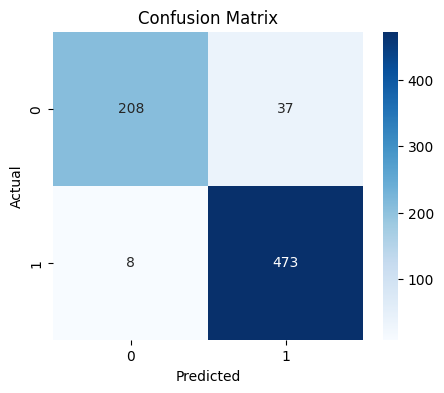

In [57]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [58]:
from sklearn.svm import SVC
model = SVC(probability=True)
params = {'kernel': ['linear', 'rbf'], 'C': np.arange(0.5,1,0.1), 'gamma': np.arange(0.01,0.05,0.01)}
cv_svm = GridSearchCV(model, param_grid=params, scoring="accuracy", n_jobs=-1,cv=5)
cv_svm.fit(X_train, y_train)
best_SVM=cv_svm.best_estimator_
y_pred = best_SVM.predict(X_test)
print(cv_svm.best_params_, cv_svm.best_score_)

{'C': 0.8999999999999999, 'gamma': 0.01, 'kernel': 'linear'} 0.8918707341682


              precision    recall  f1-score   support

           0     0.9283    0.8449    0.8846       245
           1     0.9245    0.9667    0.9451       481

    accuracy                         0.9256       726
   macro avg     0.9264    0.9058    0.9149       726
weighted avg     0.9257    0.9256    0.9247       726



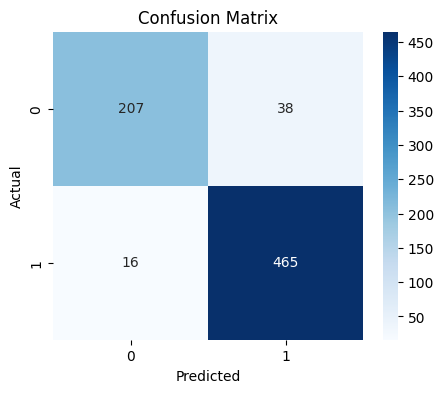

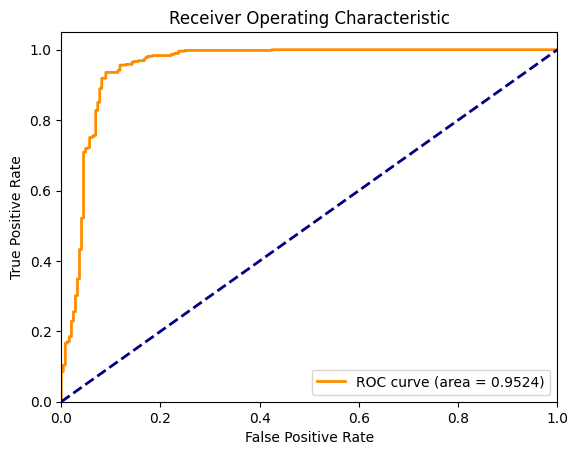

In [59]:
# Need to print the classiiofcation report , confusion matrix using heatmap

import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred,digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  Draw the roc curev and auc using the results of random forest
# ROC Curve and AUC
y_pred_proba = best_SVM.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Adaboost , XGboost = 92.5%